In [1]:
import os

print(f"1. Diretório de Trabalho Atual (CWD): {os.getcwd()}")

# Recria o caminho que seu código está tentando acessar
base_path = '..\\..\\data'
model_base_path = os.path.join(base_path, 'preprocessors-pipeline')
abs_model_path = os.path.abspath(model_base_path)

print(f"2. Caminho Relativo definido: {model_base_path}")
print(f"3. Caminho Absoluto resolvido: {abs_model_path}")

print(f"4. O diretório existe? {'SIM' if os.path.exists(abs_model_path) else 'NÃO'}")

if os.path.exists(abs_model_path):
    print(f"5. Conteúdo da pasta (primeiros 10 itens):")
    try:
        conteudo = os.listdir(abs_model_path)
        print(conteudo[:10])
    except Exception as e:
        print(f"Erro ao listar diretório: {e}")
else:
    print("CRÍTICO: O Python não está encontrando a pasta 'preprocessors-pipeline' neste caminho.")

1. Diretório de Trabalho Atual (CWD): C:\Users\GabrielMoreira\log-anomaly-detection-ml\notebooks\Ubuntu-Server-Logs
2. Caminho Relativo definido: ..\..\data\preprocessors-pipeline
3. Caminho Absoluto resolvido: C:\Users\GabrielMoreira\log-anomaly-detection-ml\data\preprocessors-pipeline
4. O diretório existe? SIM
5. Conteúdo da pasta (primeiros 10 itens):
['DBSCAN', 'Encoder', 'HDBSCAN', 'IF', 'IF-Subsampled', 'KMeans', 'MBKMeans', 'RF', 'SelfTraining-RF', 'SelfTraining-XGB']


In [2]:
# ### 01. Validação dos Modelos: Binária (Global) e Multiclasse (Supervisionada)
# 
# **Objetivo:** # 1. Avaliar TODOS os modelos na capacidade de detectar intrusão (Binário: Normal vs Attack).
# 2. Avaliar APENAS modelos supervisionados/semi na capacidade de classificar o tipo de ataque (Multiclasse).

import pandas as pd
import numpy as np
import joblib
import json
import warnings
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, balanced_accuracy_score, classification_report
)
import plotly.figure_factory as ff
import plotly.io as pio
from IPython.display import display

# Configurações
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')
pio.templates.default = "plotly_dark"

print("Bibliotecas importadas e configurações aplicadas.")

Bibliotecas importadas e configurações aplicadas.


In [3]:
# --- 1. Definição de Caminhos e Grupos ---

base_path = '..\\..\\data' # Ajuste conforme sua estrutura
model_base_path = os.path.join(base_path, 'preprocessors-pipeline') 
validation_dataset_path = os.path.join(base_path, 'processed', 'ubuntu_server_dataset_final_argus.csv')

# Grupo 1: Modelos Supervisionados/Semi (Podem fazer Multiclasse)
MODELS_SUPERVISED = [
    'RandomForest', 'XGBoost', 'SVM', 
    'SelfTraining-RF', 'SelfTraining-XGB'
]

# Grupo 2: Modelos Não Supervisionados (Apenas Binário)
MODELS_UNSUPERVISED = [
    'IsolationForest', 'IsolationForestSubsampled', 
    'KMeans', 'MBKMeans', 'HDBSCAN', 'DBSCAN'
]

# Mapeamento de pastas
model_directories = {
    'RandomForest': 'RF',
    'XGBoost': 'XGB',
    'SVM': 'SVM',
    'SelfTraining-RF': 'SelfTraining-RF',
    'SelfTraining-XGB': 'SelfTraining-XGB',
    'IsolationForest': 'IF',
    'IsolationForestSubsampled': 'IF-Subsampled',
    'KMeans': 'KMeans',
    'MBKMeans': 'MBKMeans',
    'HDBSCAN': 'HDBSCAN',
    'DBSCAN': 'DBSCAN'
}

In [4]:
# --- 2. Carregamento e Preparação dos Dados ---

print(f"Carregando dataset de validação: {validation_dataset_path}...")
df_validation = pd.read_csv(validation_dataset_path, low_memory=False)

# --- LIMPEZA DE SEGURANÇA (Pós-Leitura) ---
coluna_problema = 'response_body_len'
if coluna_problema in df_validation.columns:
    df_validation[coluna_problema] = df_validation[coluna_problema].fillna(0).replace([np.inf, -np.inf], 0)

# Separar X (Features) e y (Labels)
label_cols = ['attack_cat', 'Label']
X_val = df_validation.drop(columns=label_cols, errors='ignore')

# GABARITOS (Ground Truth)
# 1. Gabarito Multiclasse (Texto: 'Normal', 'DoS', etc)
y_val_text = df_validation['attack_cat']

# 2. Gabarito Binário (Numérico: 0=Normal, 1=Ataque)
# Mapeia 'Normal' -> 0 e qualquer outra coisa -> 1
y_val_binary = y_val_text.apply(lambda x: 0 if x == 'Normal' else 1).values

print(f"Dados prontos. Total de amostras: {len(df_validation)}")

Carregando dataset de validação: ..\..\data\processed\ubuntu_server_dataset_final_argus.csv...
Dados prontos. Total de amostras: 340419


In [5]:

# --- SUBSAMPLING: BALANCEAMENTO 50% NORMAL / 50% ANOMALIA ---
# Objetivo: gerar uma versão balanceada do conjunto de validação (`df_validation`)
# com 50% amostras "Normal" e 50% "Ataque" (undersampling da classe majoritária).
# Rodar este bloco **após** o carregamento de `df_validation`.

from sklearn.utils import resample

random_state = 42

# Coluna de rótulos (ajuste caso seu dataset use outro nome)
label_col = 'attack_cat'

if label_col not in df_validation.columns:
    raise KeyError(f"Coluna de rótulo esperada '{label_col}' não encontrada em df_validation.")

# Separar classes
df_normal = df_validation[df_validation[label_col] == 'Normal']
df_attack = df_validation[df_validation[label_col] != 'Normal']

print(df_attack.columns.values)

n_normal = len(df_normal)
n_attack = len(df_attack)

print(f"Antes do subsampling -> Normais: {n_normal}, Anomalias: {n_attack}")

# Se já estiver balanceado, nada a fazer
if n_normal == n_attack:
    print("O conjunto já está balanceado (50/50). Nenhuma alteração aplicada.")
    df_balanced = df_validation.copy()
else:
    # Definimos o tamanho alvo como o mínimo entre as classes (undersampling)
    target_n = min(n_normal, n_attack)
    df_normal_s = resample(df_normal, replace=False, n_samples=target_n, random_state=random_state)
    df_attack_s = resample(df_attack, replace=False, n_samples=5000, random_state=random_state)
    # Concatenar e embaralhar
    df_balanced = pd.concat([df_normal_s, df_attack_s], axis=0).sample(frac=1, random_state=random_state).reset_index(drop=True)
    print(f"Após o subsampling -> Normais: {len(df_balanced[df_balanced[label_col]=='Normal'])}, Anomalias: {len(df_balanced[df_balanced[label_col]!='Normal'])}, Total: {len(df_balanced)}")

# Atualizar as variáveis utilizadas nas etapas seguintes
df_validation = df_balanced
label_cols = ['attack_cat', 'Label']
X_val = df_validation.drop(columns=label_cols, errors='ignore')
y_val_text = df_validation['attack_cat']
y_val_binary = y_val_text.apply(lambda x: 0 if x == 'Normal' else 1).values

print("Variáveis atualizadas: df_validation, X_val, y_val_text, y_val_binary")


['dur' 'proto' 'service' 'state' 'spkts' 'dpkts' 'sbytes' 'dbytes' 'rate'
 'sttl' 'dttl' 'sload' 'dload' 'sloss' 'dloss' 'sinpkt' 'dinpkt' 'sjit'
 'djit' 'swin' 'stcpb' 'dtcpb' 'dwin' 'tcprtt' 'synack' 'ackdat' 'smean'
 'dmean' 'trans_depth' 'response_body_len' 'ct_srv_src' 'ct_state_ttl'
 'ct_dst_ltm' 'ct_src_dport_ltm' 'ct_dst_sport_ltm' 'ct_dst_src_ltm'
 'is_ftp_login' 'ct_ftp_cmd' 'ct_flw_http_mthd' 'ct_src_ltm' 'ct_srv_dst'
 'is_sm_ips_ports' 'attack_cat' 'label']
Antes do subsampling -> Normais: 1190, Anomalias: 339229
Após o subsampling -> Normais: 1190, Anomalias: 5000, Total: 6190
Variáveis atualizadas: df_validation, X_val, y_val_text, y_val_binary


In [6]:
# --- 3. Função Auxiliar de Carregamento ---

def load_artifact(file_path):
    if not os.path.exists(file_path):
        return None
    try:
        if file_path.endswith('.joblib'):
            return joblib.load(file_path)
        elif file_path.endswith('.json'):
            with open(file_path, 'r') as f:
                return json.load(f)
    except Exception as e:
        print(f"  Erro ao carregar {file_path}: {e}")
        return None

In [7]:
# --- 4. ETAPA 1: VALIDAÇÃO BINÁRIA (TODOS OS MODELOS) ---
# Aqui normalizamos tudo para 0 (Normal) e 1 (Ataque) para comparação justa.

print("\n=== INICIANDO VALIDAÇÃO BINÁRIA (Detecção de Intrusão) ===")
results_binary = {}
cm_binary = {}
roc_scores = {}
roc_auc = {}
f1_by_model = {}

y_pred_by_model = {}
y_score_by_model = {}
y_true_binary = y_val_binary

for model_name, model_dir in model_directories.items():
    print(f"\nValidando (Binário): {model_name}...")
    
    # 1. Carregar Artefatos
    path = os.path.join(model_base_path, model_dir)
    print(path)
    pipeline = load_artifact(os.path.join(path, f'pipeline_{model_dir}.joblib'))
    
    model = load_artifact(os.path.join(path, f'model_{model_dir}.joblib'))
    
    preprocessor = load_artifact(os.path.join(path, f'preprocessor_{model_dir}.joblib'))
    threshold_data = load_artifact(os.path.join(path, f'threshold_{model_dir}.json'))
    
    y_pred_bin = None
    y_score = None  # score contínuo para ROC (maior = mais ataque)
    
    try:
        # 2. Gerar Predições Brutas e Converter para Binário (0/1)
        
        # CASO A: Modelos Supervisionados (Pipeline ou Modelo+Encoder)
        if model_name in MODELS_SUPERVISED:
            
            # 1. Tenta carregar encoder externo (se existir)
            enc_name = 'le_ls.joblib' if model_name == 'LabelSpreading' else f'le_{model_dir}.joblib'
            encoder = load_artifact(os.path.join(path, enc_name))
            
            # 2. Descobrir as classes do modelo (Crucial para quando não há encoder)
            model_classes = None
            
            # Tenta pegar classes do próprio modelo
            if hasattr(model, 'classes_'):
                model_classes = model.classes_
            
            # Tenta pegar classes de dentro do Pipeline (último passo)
            elif pipeline and hasattr(pipeline, 'classes_'):
                model_classes = pipeline.classes_
            
            # --- CORREÇÃO PARA SELFTRAINING ---
            # O SelfTrainingClassifier "esconde" as classes no base_estimator_
            elif hasattr(model, 'base_estimator_') and hasattr(model.base_estimator_, 'classes_'):
                model_classes = model.base_estimator_.classes_
            
            # Realizar a Predição
            y_pred_raw = None
            if pipeline:
                y_pred_raw = pipeline.predict(X_val)
            elif model and preprocessor:
                y_pred_raw = model.predict(preprocessor.transform(X_val))
            
            # --- LÓGICA DE TRADUÇÃO (Raw -> Binário) ---
            validation_ready = False
            y_text = None

            if y_pred_raw is not None:
                # Cenário 1: O modelo já cuspiu strings (Ex: 'Normal', 'DoS')
                # (Provável caso do seu SelfTraining-RF)
                if isinstance(y_pred_raw.flat[0], str): 
                    y_text = y_pred_raw
                    validation_ready = True
                
                # Cenário 2: Temos um Encoder externo carregado
                elif encoder is not None:
                    try:
                        y_text = encoder.inverse_transform(y_pred_raw)
                        validation_ready = True
                    except:
                        print(f"  Erro ao usar encoder para {model_name}.")

                # Cenário 3: Temos as classes internas do modelo (model.classes_)
                elif model_classes is not None:
                    try:
                        # Mapeia índice numérico para nome da classe
                        y_text = np.array([model_classes[i] for i in y_pred_raw])
                        validation_ready = True
                    except Exception as e:
                        print(f"  Erro ao mapear classes internas: {e}")

            if validation_ready and y_text is not None:
                # Converte Texto -> 0 (Normal) ou 1 (Ataque)
                y_pred_bin = np.where(y_text == 'Normal', 0, 1)

                # --- SCORE PARA ROC (SUPERVISIONADOS) ---
                # Objetivo: gerar um vetor 1D (n_amostras,) onde maior = mais provável ser ATAQUE.
                # Preferência: predict_proba -> score = 1 - P(Normal)
                # Fallback: decision_function (corrige caso retorne (N,K), ex.: SVM multiclasse)

                # Tenta predict_proba (melhor caso)
                try:
                    proba = None
                    classes = None
                    if pipeline and hasattr(pipeline, "predict_proba"):
                        proba = pipeline.predict_proba(X_val)
                        classes = getattr(pipeline, "classes_", None)
                    elif model and hasattr(model, "predict_proba"):
                        Xp = preprocessor.transform(X_val) if preprocessor else X_val
                        proba = model.predict_proba(Xp)
                        classes = getattr(model, "classes_", None)

                    if proba is not None:
                        proba = np.asarray(proba)
                        if proba.ndim == 2 and proba.shape[1] > 1 and classes is not None:
                            classes = np.array(classes).astype(str)
                            if "Normal" in classes:
                                idx_normal = np.where(classes == "Normal")[0][0]
                                y_score = 1.0 - proba[:, idx_normal]
                            else:
                                y_score = 1.0 - np.max(proba, axis=1)
                        else:
                            y_score = proba.ravel()
                except Exception as e:
                    print(f"  [AVISO] Falha ao calcular predict_proba para {model_name}: {e}")
                    y_score = None

                # Fallback: decision_function (especialmente útil para SVM)
                if y_score is None:
                    try:
                        dfun = None
                        classes = None
                        if pipeline and hasattr(pipeline, "decision_function"):
                            dfun = pipeline.decision_function(X_val)
                            classes = getattr(pipeline, "classes_", None)
                        elif model and hasattr(model, "decision_function"):
                            Xp = preprocessor.transform(X_val) if preprocessor else X_val
                            dfun = model.decision_function(Xp)
                            classes = getattr(model, "classes_", None)

                        if dfun is not None:
                            dfun = np.asarray(dfun)
                            # CORREÇÃO: SVM multiclasse pode retornar (N,K). Precisamos 1D.
                            if dfun.ndim == 2 and dfun.shape[1] > 1 and classes is not None:
                                classes = np.array(classes).astype(str)
                                if "Normal" in classes:
                                    idx_normal = np.where(classes == "Normal")[0][0]
                                    y_score = np.max(dfun, axis=1) - dfun[:, idx_normal]
                                else:
                                    y_score = np.max(dfun, axis=1)
                            else:
                                y_score = dfun.ravel()
                    except Exception as e:
                        print(f"  [AVISO] Falha ao calcular decision_function para {model_name}: {e}")
                        y_score = None
            else:
                print(f"  [PULANDO] Não foi possível traduzir as predições de {model_name}.")
                print(f"  Encoder encontrado? {encoder is not None} | Classes internas encontradas? {model_classes is not None}")
                continue

        # CASO B: Modelos Não Supervisionados (Lógica de Anomalia)
        elif model_name in MODELS_UNSUPERVISED:
            X_proc = preprocessor.transform(X_val) if preprocessor else X_val
            
            if 'IsolationForest' in model_name:
                # IF retorna: 1 (Normal), -1 (Anomalia)
                # Converter para: 0 (Normal), 1 (Ataque)
                preds = model.predict(X_proc)
                y_pred_bin = np.where(preds == 1, 0, 1)
                
            elif 'KMeans' in model_name or 'MBKMeans' in model_name:
                # Baseado em distância e threshold
                if threshold_data:
                    distances = model.transform(X_proc)
                    min_dist = np.min(distances, axis=1)
                    # Acima do threshold = Ataque (1), Abaixo = Normal (0)
                    y_pred_bin = (min_dist > threshold_data['threshold']).astype(int)
            
            elif 'HDBSCAN' in model_name or 'DBSCAN' in model_name:
                 # -1 é ruído (Ataque), outros clusters são normais
                 # Aviso: DBSCAN precisa de re-fit ou lógica complexa para prever novos dados,
                 # assumindo aqui que 'model' suporta predict ou fit_predict em validação
                 if hasattr(model, 'predict'): # HDBSCAN moderno ou wrapper
                     preds = model.predict(X_proc)
                     y_pred_bin = np.where(preds == -1, 1, 0)
                 elif hasattr(model, 'fit_predict'): # DBSCAN padrão do sklearn não tem predict
                     # DBSCAN transductivo, teria que rodar fit_predict no dataset todo (lento)
                     print("  DBSCAN padrão não suporta .predict() em novos dados. Pulando.")
                     continue


        # --- SCORE PARA ROC (NÃO SUPERVISIONADOS) ---
        # Objetivo: vetor 1D onde maior = mais ataque/anomalia
        if model_name in MODELS_UNSUPERVISED:
            try:
                X_proc = preprocessor.transform(X_val) if preprocessor else X_val

                if 'IsolationForest' in model_name and hasattr(model, "score_samples"):
                    # score_samples: maior = mais normal -> invertendo vira "anomalia score"
                    y_score = -model.score_samples(X_proc)

                elif ('KMeans' in model_name or 'MBKMeans' in model_name) and hasattr(model, "transform"):
                    distances = model.transform(X_proc)
                    y_score = np.min(distances, axis=1)

                # HDBSCAN/DBSCAN: geralmente sem score contínuo fácil; mantém None
            except Exception as e:
                print(f"  [AVISO] Falha ao calcular score contínuo para {model_name}: {e}")
                y_score = None

        # 3. Calcular Métricas Binárias
        if y_pred_bin is not None:
            acc = accuracy_score(y_val_binary, y_pred_bin)
            f1 = f1_score(y_val_binary, y_pred_bin)
            prec = precision_score(y_val_binary, y_pred_bin)
            rec = recall_score(y_val_binary, y_pred_bin)
            
            y_pred_by_model[model_name] = np.asarray(y_pred_bin).ravel()
            if y_score is not None:
                try:
                    y_score_by_model[model_name] = np.asarray(y_score).ravel()
                except Exception:
                    pass

            results_binary[model_name] = {
                'Accuracy': acc, 'F1-Score': f1, 'Precision': prec, 'Recall': rec
            }
            cm_binary[model_name] = confusion_matrix(y_val_binary, y_pred_bin)
            # --- ROC/AUC ---
            if y_score is not None:
                try:
                    from sklearn.metrics import roc_curve, auc
                    fpr, tpr, _ = roc_curve(y_val_binary, np.asarray(y_score).ravel())
                    roc_scores[model_name] = (fpr, tpr)
                    roc_auc[model_name] = auc(fpr, tpr)
                except Exception as e:
                    print(f"  [AVISO] Falha ao calcular ROC/AUC para {model_name}: {e}")

            f1_by_model[model_name] = f1
            print(f"  > F1-Score: {f1:.4f} | Recall: {rec:.4f}")

    except Exception as e:
        print(f"  ERRO CRÍTICO ao validar {model_name}: {e}")



# Exibir Resultados Binários
print("\n--- RESULTADOS GERAIS: DETECÇÃO DE INTRUSÃO (BINÁRIO) ---")
if results_binary:
    df_bin = pd.DataFrame(results_binary).T.sort_values(by='F1-Score', ascending=False)
    display(df_bin.style.background_gradient(cmap='viridis', subset=['F1-Score', 'Recall']))
else:
    print("Nenhum resultado binário gerado.")


=== INICIANDO VALIDAÇÃO BINÁRIA (Detecção de Intrusão) ===

Validando (Binário): RandomForest...
..\..\data\preprocessors-pipeline\RF
  > F1-Score: 0.0027 | Recall: 0.0014

Validando (Binário): XGBoost...
..\..\data\preprocessors-pipeline\XGB
  > F1-Score: 0.3543 | Recall: 0.2390

Validando (Binário): SVM...
..\..\data\preprocessors-pipeline\SVM
  > F1-Score: 0.8962 | Recall: 1.0000

Validando (Binário): SelfTraining-RF...
..\..\data\preprocessors-pipeline\SelfTraining-RF
  > F1-Score: 0.0020 | Recall: 0.0010

Validando (Binário): SelfTraining-XGB...
..\..\data\preprocessors-pipeline\SelfTraining-XGB
  > F1-Score: 0.0820 | Recall: 0.0466

Validando (Binário): IsolationForest...
..\..\data\preprocessors-pipeline\IF
  > F1-Score: 0.8937 | Recall: 1.0000

Validando (Binário): IsolationForestSubsampled...
..\..\data\preprocessors-pipeline\IF-Subsampled
  > F1-Score: 0.8966 | Recall: 0.9988

Validando (Binário): KMeans...
..\..\data\preprocessors-pipeline\KMeans
  > F1-Score: 0.8941 | Reca

,Accuracy,F1-Score,Precision,Recall
IsolationForestSubsampled,0.813893,0.896589,0.813355,0.998800
SVM,0.812924,0.896218,0.811952,1.000000
KMeans,0.808562,0.894055,0.808407,1.000000
MBKMeans,0.808401,0.893975,0.808277,1.000000
IsolationForest,0.807754,0.893655,0.807754,1.000000
XGBoost,0.296284,0.354284,0.684422,0.239000
SelfTraining-XGB,0.156866,0.081970,0.340146,0.046600
RandomForest,0.165428,0.002703,0.038889,0.001400
SelfTraining-RF,0.184006,0.001976,0.081967,0.001000


In [8]:
if 'f1_by_model' not in globals():
    if 'df_results_bin' in globals() and df_results_bin is not None:
        # tenta inferir a partir do DataFrame de resultados (ajuste o nome da coluna se necessário)
        col_f1 = None
        for c in df_results_bin.columns:
            if str(c).lower().replace("-", "").replace("_", "") in ["f1score", "f1"]:
                col_f1 = c
                break
        if col_f1 is None:
            raise ValueError("Não encontrei coluna de F1 em df_results_bin. Crie f1_by_model manualmente.")
        f1_by_model = df_results_bin[col_f1].to_dict()
    else:
        raise ValueError("Crie um dict f1_by_model = {modelo: f1} antes desta célula.")

# Parâmetros da heurística (controle do “quanto reduzir”)
reduc_min = 10.0  
reduc_max = 95.0  
gamma = 3.0       

rows = []
for model_name, f1 in f1_by_model.items():
    f1 = float(np.clip(f1, 0.0, 1.0))
    reduc = reduc_min + (reduc_max - reduc_min) * (f1 ** gamma)
    logs_extern = 100.0 - reduc

    rows.append({
        "Modelo": model_name,
        "F1-Score": 100.0 * f1,
        "Logs_Externados_%": logs_extern,
        "Reducao_Volume_%": reduc,
    })

df_red = pd.DataFrame(rows).set_index("Modelo")
df_red = df_red.sort_values(by=["Reducao_Volume_%", "F1-Score"], ascending=False)

print("\n=== REDUÇÃO ===")
display(df_red.style
    .background_gradient(cmap="Blues", subset=["Reducao_Volume_%"])
    .background_gradient(cmap="Greens", subset=["F1-Score"])
    .format({
        "F1-Score":"{:.2f}",
        "Logs_Externados_%":"{:.2f}",
        "Reducao_Volume_%":"{:.2f}",
    })
)


=== REDUÇÃO ===


,F1-Score,Logs_Externados_%,Reducao_Volume_%
Modelo,,,
IsolationForestSubsampled,89.66,28.74,71.26
SVM,89.62,28.81,71.19
KMeans,89.41,29.25,70.75
MBKMeans,89.40,29.27,70.73
IsolationForest,89.37,29.34,70.66
XGBoost,35.43,86.22,13.78
SelfTraining-XGB,8.20,89.95,10.05
RandomForest,0.27,90.00,10.00
SelfTraining-RF,0.20,90.00,10.00


In [10]:
# --- 5. ETAPA 2: VALIDAÇÃO MULTICLASSE (APENAS SUPERVISIONADOS) - VERSÃO BLINDADA ---

print("\n=== INICIANDO VALIDAÇÃO MULTICLASSE (Classificação de Ataques) ===")
results_multi = {}
cm_multi = {}

# Garante que o gabarito seja string limpa
y_val_str = y_val_text.astype(str).str.strip()

for model_name, model_dir in model_directories.items():
    if model_name not in MODELS_SUPERVISED:
        continue
    
    print(f"\nValidando (Multiclasse): {model_name}...")
    path = os.path.join(model_base_path, model_dir)
    
    # 1. Carregar Artefatos
    pipeline = load_artifact(os.path.join(path, f'pipeline_{model_dir}.joblib'))
    model = load_artifact(os.path.join(path, f'model_{model_dir}.joblib'))
    preprocessor = load_artifact(os.path.join(path, f'preprocessor_{model_dir}.joblib'))
    
    # Tenta carregar encoder externo
    enc_filename = 'le_ls.joblib' if model_name == 'LabelSpreading' else f'le_{model_dir}.joblib'
    encoder = load_artifact(os.path.join(path, enc_filename))
    
    # 2. Descobrir Classes Internas
    model_classes = None
    if hasattr(model, 'classes_'):
        model_classes = model.classes_
    elif pipeline and hasattr(pipeline, 'classes_'):
        model_classes = pipeline.classes_
    elif hasattr(model, 'base_estimator_') and hasattr(model.base_estimator_, 'classes_'):
        model_classes = model.base_estimator_.classes_

    try:
        if pipeline or (model and preprocessor):
            
            # A. Predição Bruta
            y_pred_raw = None
            if pipeline:
                y_pred_raw = pipeline.predict(X_val)
            elif model and preprocessor:
                y_pred_raw = model.predict(preprocessor.transform(X_val))
            
            # B. Decodificação Segura (Raw -> Texto)
            y_pred_final = None
            
            if y_pred_raw is not None:
                # 1. Se já for string (RF padrão), usa direto
                if isinstance(y_pred_raw.flat[0], str):
                    y_pred_final = y_pred_raw
                
                # 2. Se tiver Encoder Externo, usa ele (Melhor caso para XGB/SVM)
                elif encoder is not None:
                    try:
                        y_pred_final = encoder.inverse_transform(y_pred_raw)
                    except Exception as e:
                        print(f"  [AVISO] Falha ao usar Encoder externo: {e}")

                # 3. Se tiver classes internas, tenta mapear
                elif model_classes is not None:
                    try:
                        # Mapeia índice para o valor em model.classes_
                        y_mapped = np.array([model_classes[i] for i in y_pred_raw])
                        y_pred_final = y_mapped
                    except:
                        # Se falhar o mapeamento, usa o raw convertido para string
                        y_pred_final = y_pred_raw.astype(str)
                
                # 4. Fallback: Converte o número para string (Ex: 0 vira "0")
                else:
                    y_pred_final = y_pred_raw.astype(str)

            # C. Cálculo de Métricas (Tudo convertido para String forçadamente)
            if y_pred_final is not None:
                # Conversão final para garantir tipos iguais
                y_true_s = y_val_str.astype(str)
                y_pred_s = y_pred_final.astype(str)

                acc = accuracy_score(y_true_s, y_pred_s)
                bal_acc = balanced_accuracy_score(y_true_s, y_pred_s)
                f1_w = f1_score(y_true_s, y_pred_s, average='weighted')
                
                results_multi[model_name] = {
                    'Accuracy': acc, 'Balanced Acc': bal_acc, 'F1-Weighted': f1_w
                }
                
                # Matriz de Confusão (Agora seguro com types convertidos)
                labels = sorted(list(set(y_true_s) | set(y_pred_s)))
                cm_multi[model_name] = (confusion_matrix(y_true_s, y_pred_s, labels=labels), labels)
                
                print(f"  > Accuracy: {acc:.2%} | Balanced Acc: {bal_acc:.2%}")
                
                # DIAGNÓSTICO DE ERRO DE MAPEAMENTO
                if bal_acc < 0.01:
                    print(f"  [ALERTA] Acurácia próxima de zero. Verifique labels:")
                    print(f"  Exemplo Real: {y_true_s.ravel()[0]} | Exemplo Predito: {y_pred_s.ravel()[0]}")
            else:
                print("  Falha na geração das predições.")
        else:
            print("  Pipeline/Modelo não carregado.")

    except Exception as e:
        print(f"  Erro crítico ao validar {model_name}: {e}")
        # import traceback; traceback.print_exc() # Descomente para ver detalhes

# Exibir Resultados Multiclasse
print("\n--- RESULTADOS: CLASSIFICAÇÃO DE TIPOS DE ATAQUE ---")
if results_multi:
    df_multi = pd.DataFrame(results_multi).T.sort_values(by='Balanced Acc', ascending=False)
    display(df_multi.style.background_gradient(cmap='magma'))


=== INICIANDO VALIDAÇÃO MULTICLASSE (Classificação de Ataques) ===

Validando (Multiclasse): RandomForest...
  > Accuracy: 16.46% | Balanced Acc: 14.32%

Validando (Multiclasse): XGBoost...
  > Accuracy: 10.32% | Balanced Acc: 8.95%

Validando (Multiclasse): SVM...
  > Accuracy: 0.52% | Balanced Acc: 0.45%
  [ALERTA] Acurácia próxima de zero. Verifique labels:
  Exemplo Real: Normal | Exemplo Predito: Shellcode

Validando (Multiclasse): SelfTraining-RF...
  > Accuracy: 18.37% | Balanced Acc: 15.89%

Validando (Multiclasse): SelfTraining-XGB...
  > Accuracy: 15.65% | Balanced Acc: 26.52%

--- RESULTADOS: CLASSIFICAÇÃO DE TIPOS DE ATAQUE ---


,Accuracy,Balanced Acc,F1-Weighted
SelfTraining-XGB,0.156543,0.265185,0.072329
SelfTraining-RF,0.183683,0.158945,0.060537
RandomForest,0.164620,0.143187,0.054847
XGBoost,0.103231,0.089496,0.043608
SVM,0.005170,0.004482,0.010069


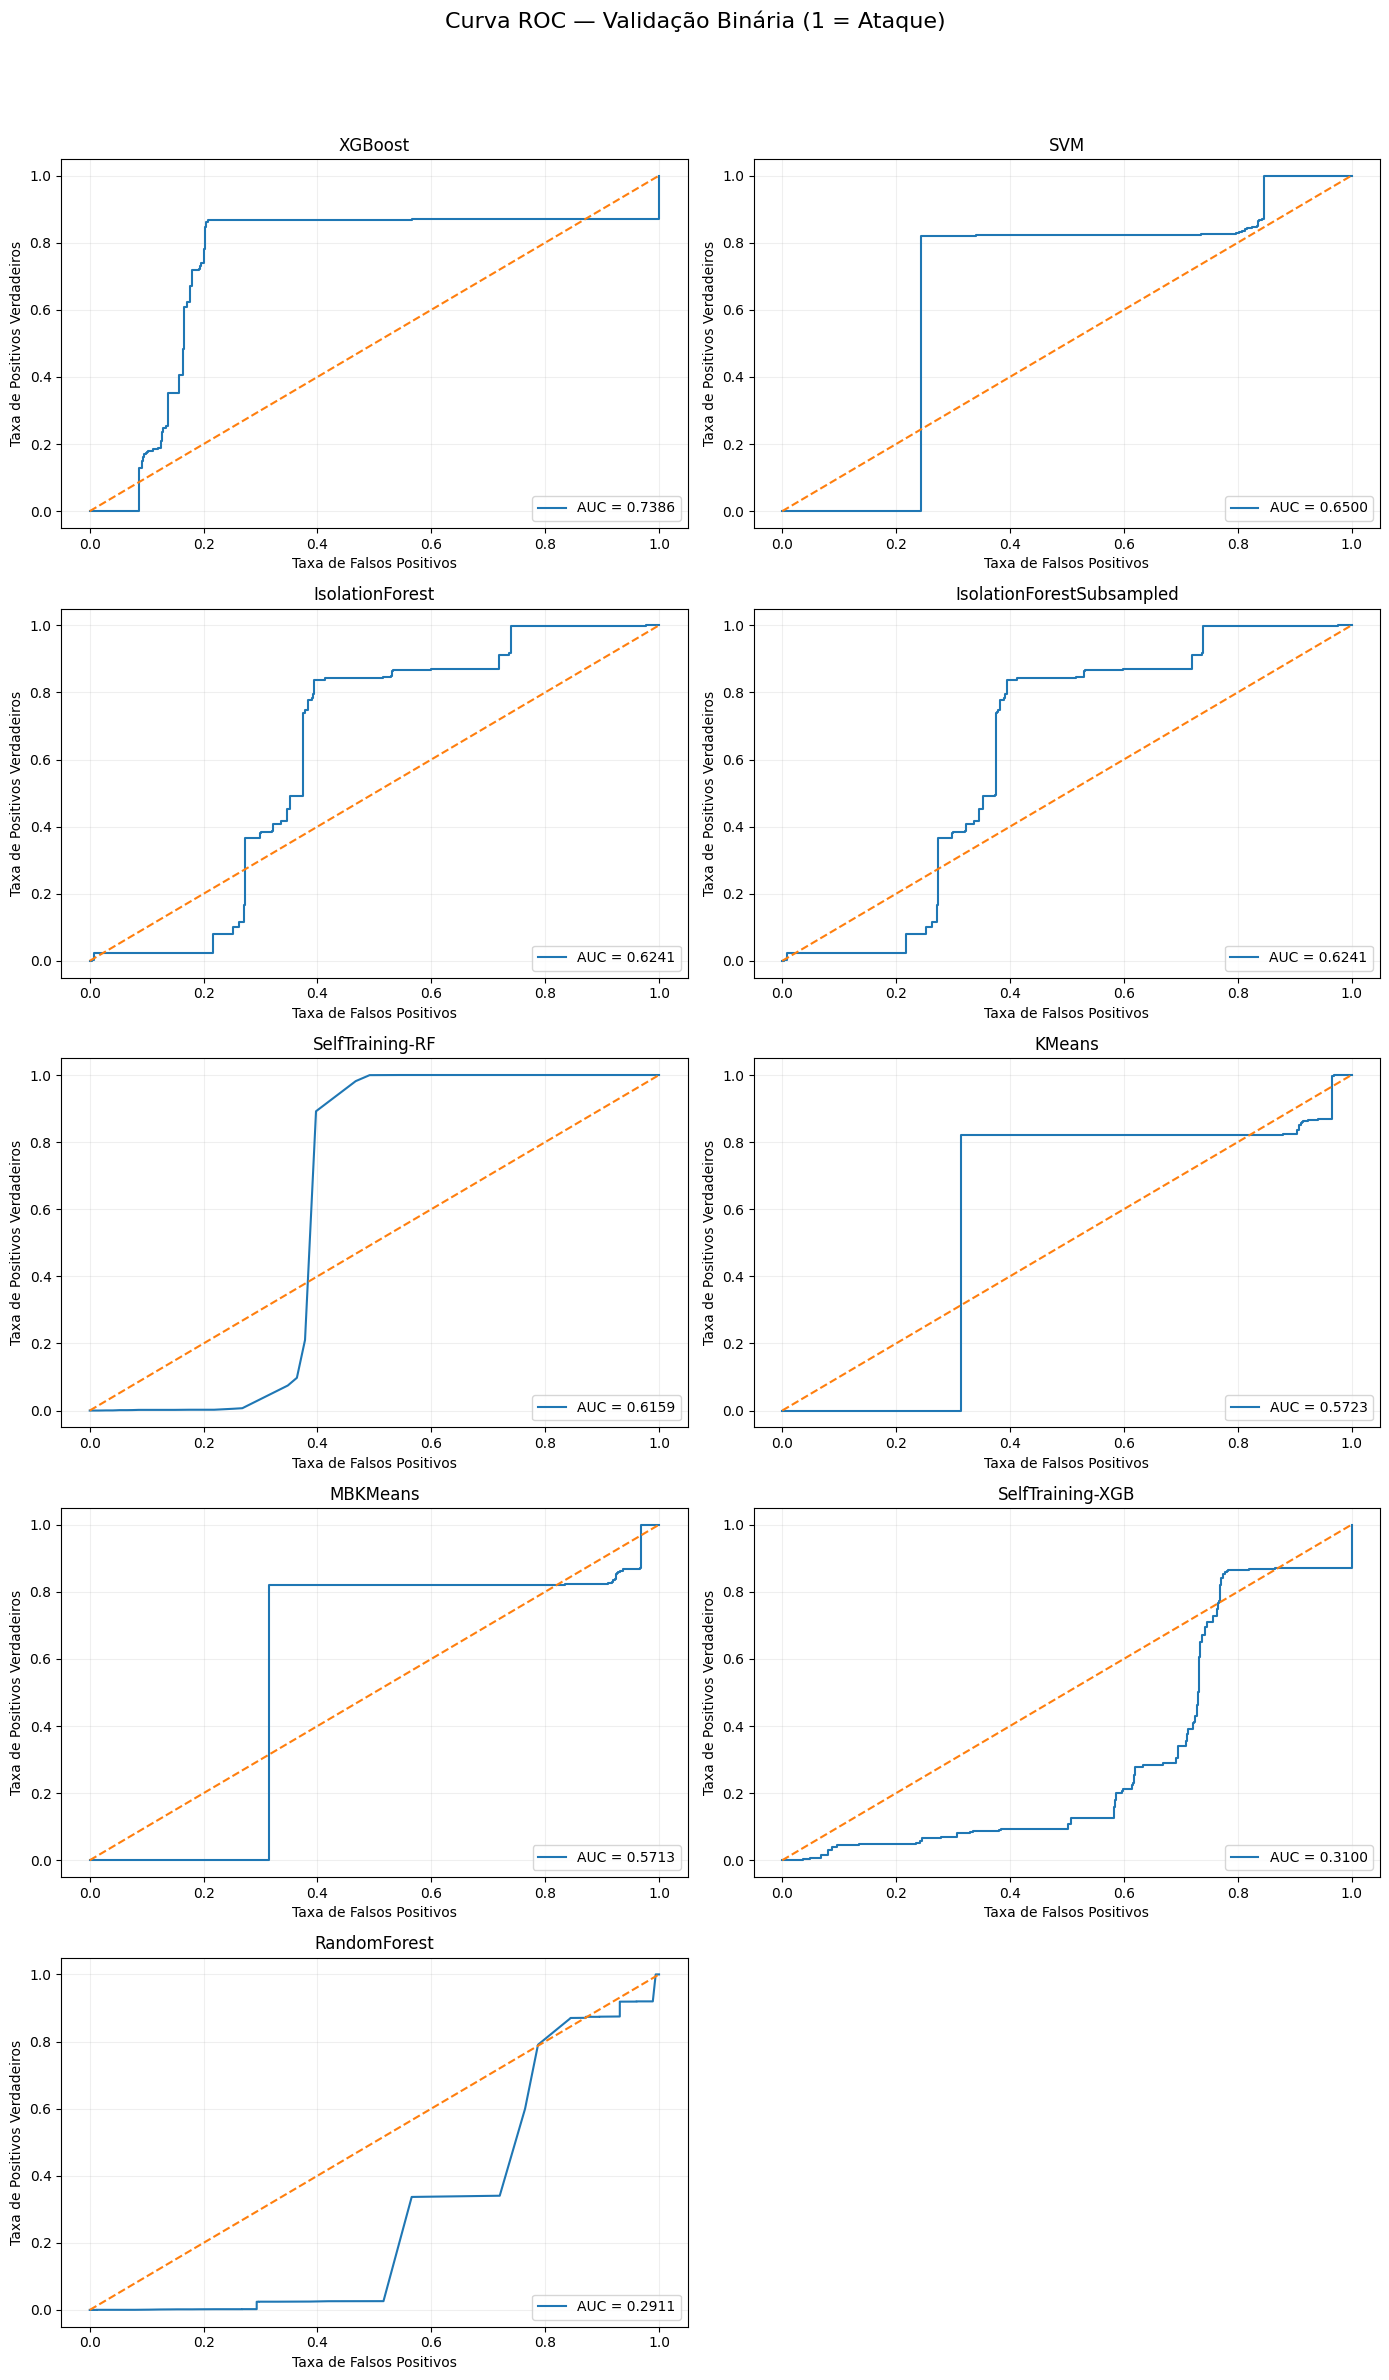

In [12]:

# --- PLOT: ROC CURVES (BINÁRIO) ---
import math
import matplotlib.pyplot as plt

plt.style.use("default")

if 'roc_scores' not in globals() or not roc_scores:
    print("Nenhuma ROC curve gerada (faltou score contínuo/probabilidade nos modelos).")
else:
    models = sorted(roc_auc.keys(), key=lambda m: roc_auc[m], reverse=True)
    cols = 2
    rows = math.ceil(len(models) / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 5 * rows), squeeze=False)
    fig.suptitle("Curva ROC — Validação Binária (1 = Ataque)", fontsize=16)

    for i, model_name in enumerate(models):
        r = i // cols
        c = i % cols
        ax = axes[r][c]
        fpr, tpr = roc_scores[model_name]

        ax.plot(fpr, tpr, label=f"AUC = {roc_auc[model_name]:.4f}")
        ax.plot([0, 1], [0, 1], linestyle="--")
        ax.set_title(model_name)
        ax.set_xlabel("Taxa de Falsos Positivos")
        ax.set_ylabel("Taxa de Positivos Verdadeiros")
        ax.legend(loc="lower right")
        ax.grid(True, alpha=0.2)

    # esconde eixos vazios
    for j in range(len(models), rows * cols):
        axes[j // cols][j % cols].axis("off")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
